In [1]:
import pandas as pd
import numpy as np
import feature_selection as fs
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from catboost import CatBoostClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import model as m
import catboost_model as miaw

2024-11-08 13:14:31.795985: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 13:14:31.820682: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-08 13:14:31.948623: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-08 13:14:31.948696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-08 13:14:31.969389: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

This is to see for the sarcopenia data only

In [2]:
filepath = '/home/karen/Documents/phd/Data/RNAseq_All_abundances_adjusted.csv'
eigth_bins_original = pd.read_csv(filepath)
eigth_bins_original.head()

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age
0,SRR13388732,-0.025109,-0.028258,-0.005872,-0.026729,-0.026472,-0.027634,-0.020870,-0.022772,-0.022661,...,-0.028169,-0.028120,-0.028027,-0.027546,-0.028289,-0.028272,-0.024716,-0.028265,GSE164471,23.0
1,SRR13388733,-0.026260,-0.033508,-0.004524,-0.028312,-0.031995,-0.032750,-0.016343,-0.026733,-0.023806,...,-0.033510,-0.033522,-0.033509,-0.032635,-0.033518,-0.033482,-0.020903,-0.032705,GSE164471,28.0
2,SRR13388734,-0.030608,-0.037952,-0.002987,-0.034886,-0.029932,-0.038745,-0.014741,-0.030696,-0.027022,...,-0.038155,-0.039709,-0.039524,-0.038657,-0.039251,-0.039648,-0.036926,-0.038901,GSE164471,31.0
3,SRR13388735,-0.021728,-0.024309,-0.004225,-0.022910,-0.023840,-0.024011,-0.019799,-0.021443,-0.022365,...,-0.024390,-0.024440,-0.024351,-0.023795,-0.024435,-0.024431,-0.021008,-0.024095,GSE164471,31.0
4,SRR13388736,-0.019503,-0.034629,-0.004944,-0.031244,-0.026323,-0.034354,-0.021341,-0.015501,-0.017102,...,-0.034285,-0.033820,-0.034226,-0.033922,-0.035173,-0.035132,-0.031649,-0.034687,GSE164471,35.0


In [3]:
eigth_bins_original=eigth_bins_original[eigth_bins_original["Experiment"]=="GSE167186"]
eigth_bins_original.head()

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age
135,SRR13758984,-0.018098,-0.039567,-0.004998,-0.033974,-0.035383,-0.037015,-0.021806,-0.029360,-0.023883,...,-0.039049,-0.039010,-0.038975,-0.037070,-0.038994,-0.038958,-0.027188,-0.038851,GSE167186,91.0
136,SRR13758985,-0.021714,-0.026491,-0.003711,-0.024397,-0.024751,-0.025862,-0.016819,-0.022847,-0.020888,...,-0.026289,-0.026413,-0.026331,-0.026158,-0.026407,-0.026438,-0.022984,-0.026243,GSE167186,86.0
137,SRR13758986,-0.025526,-0.027849,-0.004777,-0.025392,-0.025384,-0.027021,-0.020357,-0.023013,-0.020575,...,-0.027615,-0.027722,-0.027645,-0.027292,-0.027715,-0.027739,-0.030522,-0.027553,GSE167186,69.0
138,SRR13758987,-0.013807,-0.025538,-0.004040,-0.023699,-0.023917,-0.025049,-0.018966,-0.022372,-0.019911,...,-0.025359,-0.025495,-0.025410,-0.025362,-0.025489,-0.025526,-0.023519,-0.025324,GSE167186,83.0
139,SRR13758988,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,...,-0.027938,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,GSE167186,71.0


In [4]:
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(eigth_bins_original, seq_metadata, on='Sample', how='inner')
rnaSeq_origial.head()

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,Status,Sex
0,SRR13758984,-0.018098,-0.039567,-0.004998,-0.033974,-0.035383,-0.037015,-0.021806,-0.029360,-0.023883,...,-0.038975,-0.037070,-0.038994,-0.038958,-0.027188,-0.038851,GSE167186,91.0,Sarcopenia,NaN
1,SRR13758985,-0.021714,-0.026491,-0.003711,-0.024397,-0.024751,-0.025862,-0.016819,-0.022847,-0.020888,...,-0.026331,-0.026158,-0.026407,-0.026438,-0.022984,-0.026243,GSE167186,86.0,Healthy,male
2,SRR13758986,-0.025526,-0.027849,-0.004777,-0.025392,-0.025384,-0.027021,-0.020357,-0.023013,-0.020575,...,-0.027645,-0.027292,-0.027715,-0.027739,-0.030522,-0.027553,GSE167186,69.0,Healthy,male
3,SRR13758987,-0.013807,-0.025538,-0.004040,-0.023699,-0.023917,-0.025049,-0.018966,-0.022372,-0.019911,...,-0.025410,-0.025362,-0.025489,-0.025526,-0.023519,-0.025324,GSE167186,83.0,Sarcopenia,NaN
4,SRR13758988,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,...,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,GSE167186,71.0,Healthy,NaN


In [5]:
len(rnaSeq_origial)

75

In [6]:
x_labels= rnaSeq_origial["Status"].value_counts()

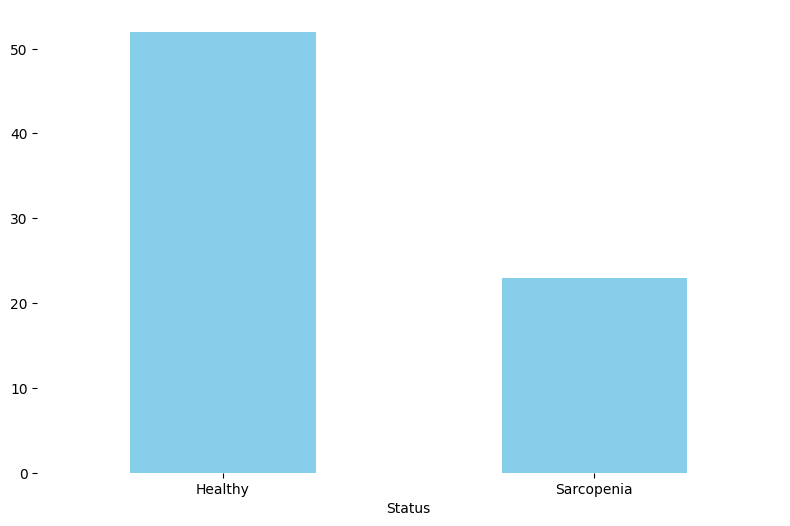

In [7]:
status_counts = rnaSeq_origial["Status"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)

plt.xticks(rotation=0)
plt.show()

In [8]:
rnaSeq_origial["Age_C"] = np.where(rnaSeq_origial["Age"] > 65, "Old", "Young")
rnaSeq_origial["Class"]=rnaSeq_origial["Status"].astype(str) +" "+ rnaSeq_origial["Age_C"].astype(str)




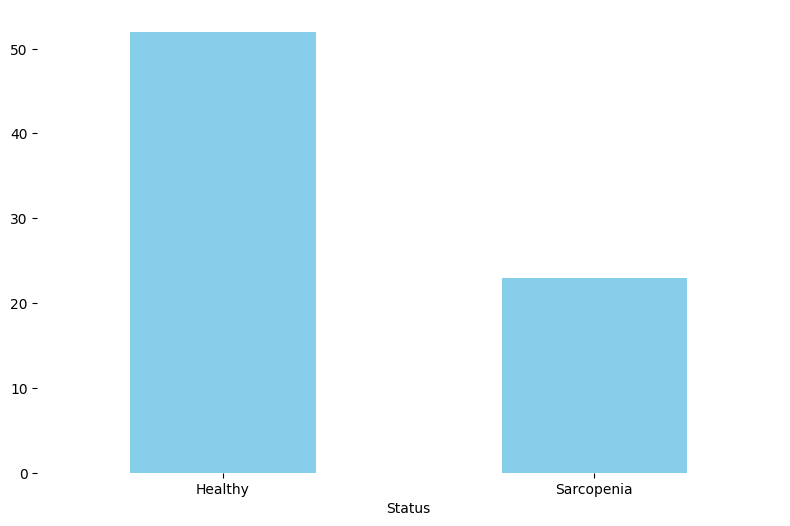

In [9]:
status_counts = rnaSeq_origial["Status"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)

plt.xticks(rotation=0)
plt.show()

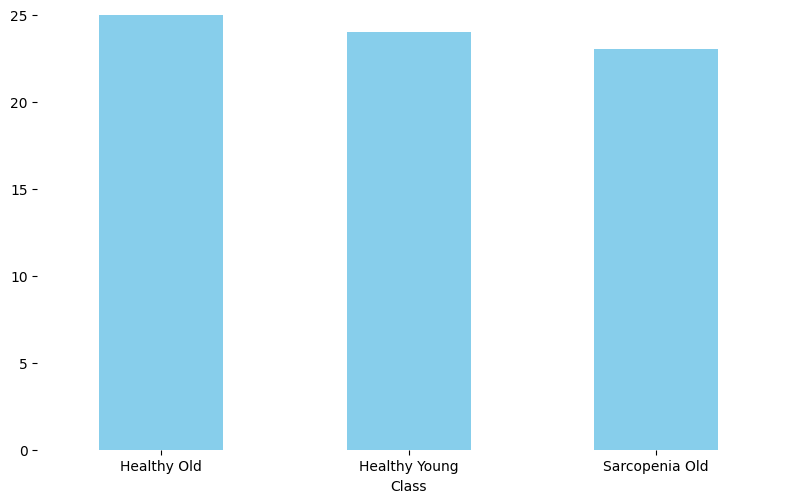

In [10]:
status_counts = rnaSeq_origial["Class"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

In [11]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]=="Old"]
len(remove_youn)

51

In [38]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"], axis=1), remove_youn["Status"], remove_youn["Age"], test_size=0.2, random_state=42)


In [13]:
len(seq_X_train), len(seq_X_test)

(40, 11)

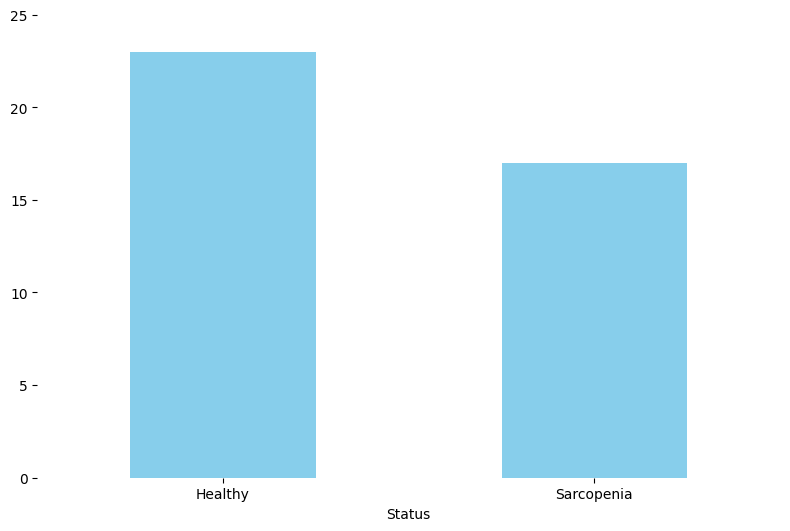

In [14]:
status_counts = seq_y_train.value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

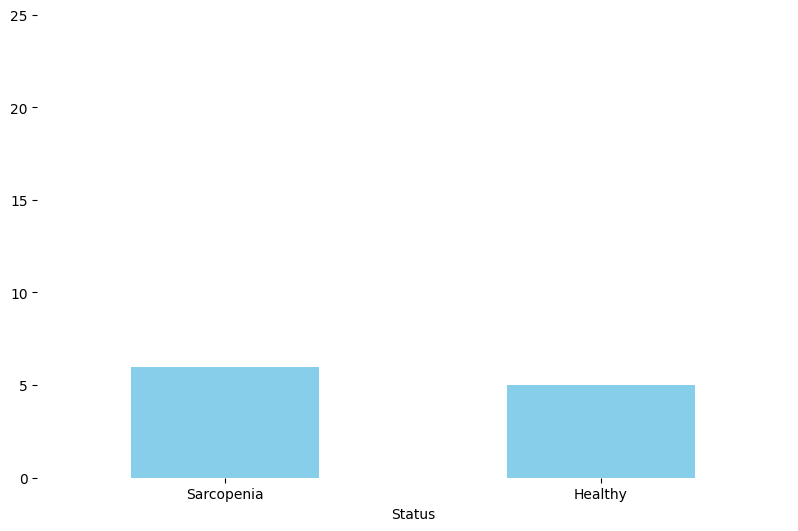

In [15]:
status_counts = seq_y_test.value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

In [16]:
train_df = pd.concat([seq_X_train, seq_y_train], axis=1)
train_df.columns=seq_X_train.columns.tolist()+["Age"]
train_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
9,-0.023128,-0.024002,-0.003397,-0.022575,-0.022527,-0.023739,-0.019233,-0.020894,-0.019544,-0.021091,...,-0.024046,-0.023860,-0.024016,-0.023924,-0.024081,-0.024011,-0.024056,-0.026061,-0.023843,Sarcopenia
73,-0.026103,-0.029423,-0.004575,-0.026544,-0.026744,-0.028363,-0.019292,-0.022720,-0.020099,-0.024623,...,-0.029254,-0.029150,-0.029237,-0.029166,-0.028604,-0.029229,-0.029245,-0.026252,-0.029070,Sarcopenia
7,-0.021289,-0.024118,-0.003147,-0.022659,-0.022674,-0.023838,-0.017984,-0.021239,-0.019583,-0.021028,...,-0.024157,-0.023973,-0.024127,-0.024036,-0.024177,-0.024122,-0.024166,-0.030709,-0.023954,Sarcopenia
70,-0.023240,-0.028247,-0.003849,-0.025683,-0.025417,-0.027360,-0.019115,-0.022428,-0.021484,-0.024813,...,-0.028124,-0.028002,-0.028105,-0.028029,-0.027623,-0.028097,-0.028120,-0.029198,-0.027936,Healthy
4,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,-0.024766,...,-0.028060,-0.027938,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,Healthy


In [17]:
smote = fs.get_feature_SMOTE(train_df, is_categorical=True, strategy={'Sarcopenia': 30, 'Healthy': 30} )


Class distribution before SMOTE: Counter({'Healthy': 23, 'Sarcopenia': 17})
Class distribution after SMOTE: Counter({'Sarcopenia': 30, 'Healthy': 30})


In [18]:
#(sampling_strategy={0: 30, 1: 30}

In [19]:

train_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
9,-0.023128,-0.024002,-0.003397,-0.022575,-0.022527,-0.023739,-0.019233,-0.020894,-0.019544,-0.021091,...,-0.024046,-0.023860,-0.024016,-0.023924,-0.024081,-0.024011,-0.024056,-0.026061,-0.023843,Sarcopenia
73,-0.026103,-0.029423,-0.004575,-0.026544,-0.026744,-0.028363,-0.019292,-0.022720,-0.020099,-0.024623,...,-0.029254,-0.029150,-0.029237,-0.029166,-0.028604,-0.029229,-0.029245,-0.026252,-0.029070,Sarcopenia
7,-0.021289,-0.024118,-0.003147,-0.022659,-0.022674,-0.023838,-0.017984,-0.021239,-0.019583,-0.021028,...,-0.024157,-0.023973,-0.024127,-0.024036,-0.024177,-0.024122,-0.024166,-0.030709,-0.023954,Sarcopenia
70,-0.023240,-0.028247,-0.003849,-0.025683,-0.025417,-0.027360,-0.019115,-0.022428,-0.021484,-0.024813,...,-0.028124,-0.028002,-0.028105,-0.028029,-0.027623,-0.028097,-0.028120,-0.029198,-0.027936,Healthy
4,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,-0.024766,...,-0.028060,-0.027938,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,Healthy


In [20]:
#train_df["Age"]=smote[1]
train_df["Age"] = train_df["Age"].map({"Healthy": 0, "Sarcopenia": 1})


In [21]:
train_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
9,-0.023128,-0.024002,-0.003397,-0.022575,-0.022527,-0.023739,-0.019233,-0.020894,-0.019544,-0.021091,...,-0.024046,-0.023860,-0.024016,-0.023924,-0.024081,-0.024011,-0.024056,-0.026061,-0.023843,1
73,-0.026103,-0.029423,-0.004575,-0.026544,-0.026744,-0.028363,-0.019292,-0.022720,-0.020099,-0.024623,...,-0.029254,-0.029150,-0.029237,-0.029166,-0.028604,-0.029229,-0.029245,-0.026252,-0.029070,1
7,-0.021289,-0.024118,-0.003147,-0.022659,-0.022674,-0.023838,-0.017984,-0.021239,-0.019583,-0.021028,...,-0.024157,-0.023973,-0.024127,-0.024036,-0.024177,-0.024122,-0.024166,-0.030709,-0.023954,1
70,-0.023240,-0.028247,-0.003849,-0.025683,-0.025417,-0.027360,-0.019115,-0.022428,-0.021484,-0.024813,...,-0.028124,-0.028002,-0.028105,-0.028029,-0.027623,-0.028097,-0.028120,-0.029198,-0.027936,0
4,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,-0.024766,...,-0.028060,-0.027938,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,0


In [22]:
#params_c = miaw.optimize_data_classification(train_df)


In [23]:
#params = {'iterations': 167, 'learning_rate': 0.003873552369834775, 'depth': 3, 'loss_function': 'Logloss'}
params: {'iterations': 210, 'learning_rate': 0.006656053775425384, 'depth': 5, 'l2_leaf_reg': 0.17493726220141959}

In [24]:
X = seq_X_train
y = seq_y_train
classifier = CatBoostClassifier(iterations=150,  # Number of boosting iterations
                              learning_rate=0.05,  # Learning rate
                              depth=5,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose=1)  # Verbosity level (0 - silent, 1 - verbose)
classifier = CatBoostClassifier(**params, verbose=0)

# Fit the model
classifier.fit(X, y, eval_set=(seq_X_test,seq_y_test),use_best_model=True, plot=True)



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6760868	test: 0.6884411	best: 0.6884411 (0)	total: 499ms	remaining: 1m 14s
1:	learn: 0.6462337	test: 0.6825649	best: 0.6825649 (1)	total: 853ms	remaining: 1m 3s
2:	learn: 0.6108554	test: 0.6569785	best: 0.6569785 (2)	total: 1.16s	remaining: 56.8s
3:	learn: 0.5871284	test: 0.6497796	best: 0.6497796 (3)	total: 1.45s	remaining: 52.8s
4:	learn: 0.5716480	test: 0.6384468	best: 0.6384468 (4)	total: 1.76s	remaining: 51.1s
5:	learn: 0.5483440	test: 0.6291663	best: 0.6291663 (5)	total: 2.08s	remaining: 49.8s
6:	learn: 0.5253865	test: 0.6325694	best: 0.6291663 (5)	total: 2.47s	remaining: 50.5s
7:	learn: 0.5040678	test: 0.6249574	best: 0.6249574 (7)	total: 2.81s	remaining: 49.8s
8:	learn: 0.4797556	test: 0.6291945	best: 0.6249574 (7)	total: 3.13s	remaining: 49s
9:	learn: 0.4614116	test: 0.6218588	best: 0.6218588 (9)	total: 3.52s	remaining: 49.3s
10:	learn: 0.4458699	test: 0.6166796	best: 0.6166796 (10)	total: 3.89s	remaining: 49.1s
11:	learn: 0.4345045	test: 0.6167245	best: 0.6166796 

In [25]:
from catboost import Pool, cv
import pandas as pd
import numpy as np


from sklearn.metrics import matthews_corrcoef

from sklearn.model_selection import train_test_split
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score


from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
scorer = make_scorer(matthews_corrcoef)
seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000, 100000],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001],  # Kernel coefficient for 'rbf' and 'poly'
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],  # Kernel type
}

# Create SVM model
svm_model = SVC()

# Perform grid search with cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring=scorer)
grid_search.fit(seq_X_train, seq_y_train)

# Get best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score (mcc):", best_score)

# Use best model for prediction
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(seq_X_test)
y_pred

/tmp/ipykernel_15783/2028479386.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
/tmp/ipykernel_15783/2028479386.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})


Best Parameters: {'C': 100000, 'gamma': 0.0001, 'kernel': 'sigmoid'}
Best Score (mcc): 0.4671723342064289


array([1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1])

In [27]:
best_svm_model = grid_search.best_estimator_


In [28]:
y_pred = best_svm_model.predict(seq_X_train)

conf_matrix_train = confusion_matrix(seq_y_train, y_pred)
print(conf_matrix_train)

[[17  6]
 [ 5 12]]


In [42]:
mapp_test = seq_y_test.map({"Healthy": 0, "Sarcopenia": 1})

In [43]:
y_pred = best_svm_model.predict(seq_X_test)

conf_matrix_train = confusion_matrix(mapp_test, y_pred)
print(conf_matrix_train)

[[3 2]
 [3 3]]


In [44]:
# Make predictions
seq_auc = accuracy_score(mapp_test, y_pred)
seq_results = pd.DataFrame({'Actual': mapp_test, 'Predicted': y_pred})
seq_auc

0.5454545454545454

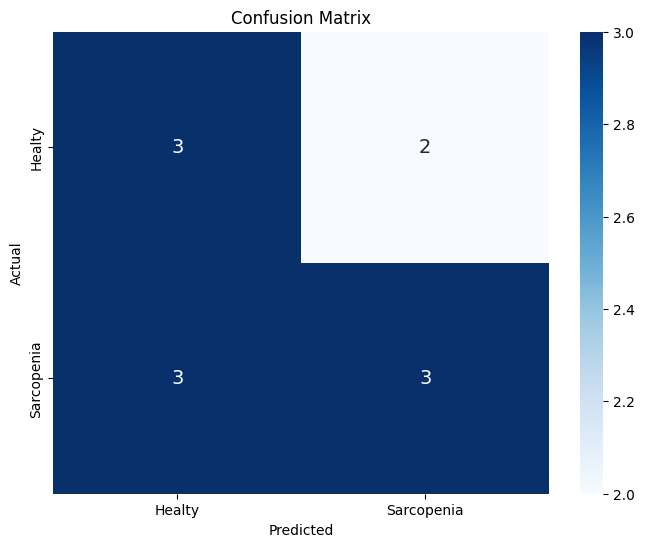

In [45]:
conf_matrix = confusion_matrix(mapp_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
predictions

In [ ]:
training_predictions = best_model.predict(X)
training_auc = roc_auc_score(y, training_predictions)
training_auc


In [30]:
from sklearn.metrics import confusion_matrix


In [ ]:
training_predictions = best_model.predict(X)
training_auc = roc_auc_score(y, training_predictions)
training_auc
conf_matrix = confusion_matrix(y, training_predictions)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
explainer = shap.Explainer(best_model)
shap_values = explainer.shap_values(X)
importance = best_model.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
gene_names = [
("ENSG00000101892.11","ATP1B4"),
("ENSG00000201766.1","RNA5SP302"),
("ENSG00000127241.16","MASP1"),
("ENSG00000277654.5","AC087633.2"),
("ENSG00000145949.10","MYLK4"),
("ENSG00000171055.14","FEZ2"),
("ENSG00000198712.1","MT-CO2"),
("ENSG00000164104.11","HMGB2"),
("ENSG00000172399.5","MYOZ2"),
("ENSG00000177548.12","RABEP2"),
("ENSG00000089101.17","CFAP61"),
("ENSG00000003989.17","SLC7A2"),
("ENSG00000137700.17","SLC37A4"),
("ENSG00000174227.15","PIGG"),
("ENSG00000133020.4","MYH8"),
("ENSG00000252262.1","RNA5SP61"),
("ENSG00000234441.1","AC105272.1"),
("ENSG00000247627.2","MTND4P12"),
("ENSG00000100568.10","VTI1B"),
("ENSG00000237973.1","MTCO1P12"),
("ENSG00000170873.18","MTSS1"),
("ENSG00000082397.17"	,"EPB41L3"),
("ENSG00000111640.14"	,"GAPDH")
]

for gene_id, gene_name in gene_names:
    if gene_id in X.columns:
        X.rename(columns={gene_id: gene_name}, inplace=True)

shap.summary_plot(shap_values, X, max_display=10)


In [ ]:
best_model.classes_

In [ ]:
feature_imporance_df.head(50)

In [ ]:
seq_y_test_map = seq_y_test.copy()

test_predictions = best_model.predict(seq_X_test)
test_auc = roc_auc_score(seq_y_test_map, test_predictions)
test_auc
conf_matrix = confusion_matrix(seq_y_test_map, test_predictions)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_y_test

## Using pre selected genes

In [ ]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)

In [ ]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Status")
eigth_bins_filteres = remove_youn[rnaseq_genes]
eigth_bins_filteres.head()


In [44]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(eigth_bins_filteres.drop(["Status"], axis=1), eigth_bins_filteres["Status"], remove_youn["Status"], test_size=0.1, random_state=42)
